# **1. Mounting Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **2. Install Dependencies for PySpark**

I installed Java, PySpark, findspark, and the additional libraries needed for SHAP analysis and plotting.

In [2]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq > /dev/null
!pip install -q -U "pyspark[connect]~=4.0.0" findspark shap scikit-learn matplotlib pandas

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 272.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


# **3. SparkSession Initialisation**

In [3]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType
from pyspark.ml.linalg import Vectors, SparseVector, DenseVector, VectorUDT
from pyspark.ml import PipelineModel
import numpy as np

spark = (
    SparkSession.builder
    .appName("AmazonAutomotiveEvaluation")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version : {spark.version}")

Spark version : 4.0.4


# **4. Loading Test Data and Saved Models**


In [4]:
output_dir = "/content/drive/MyDrive/amazon_automotive_sentiment"
models_dir = f"{output_dir}/models"

testing_data = spark.read.parquet(f"{output_dir}/testing_data.parquet")
testing_sample = testing_data.sample(fraction=0.004, seed=42)

target = "sentiment"

logit_model  = PipelineModel.load(f"{models_dir}/logistic_regression")
forest_model = PipelineModel.load(f"{models_dir}/random_forest")
gbt_model    = PipelineModel.load(f"{models_dir}/gbt")
nbayes_model = PipelineModel.load(f"{models_dir}/naive_bayes")

print(f"Test sample rows : {testing_sample.count():,}")
print("All four models loaded successfully.")

Test sample rows : 15,788
All four models loaded successfully.


# **5. Generating Predictions for All Four Models**

I ran predictions from each model on the same test sample, so every comparison in this notebook uses identical data.

In [5]:
logit_preds  = logit_model.transform(testing_sample)
forest_preds = forest_model.transform(testing_sample)
gbt_preds    = gbt_model.transform(testing_sample)
nbayes_preds = nbayes_model.transform(testing_sample)

model_predictions = {
    "Logistic Regression": logit_preds,
    "Random Forest": forest_preds,
    "Gradient Boosted Trees": gbt_preds,
    "Naive Bayes": nbayes_preds
}

print("Predictions generated for all four models.")

Predictions generated for all four models.


# **6. Full Metrics Comparison Table**

I computed AUC, accuracy, precision, recall, and F1 for all four models on the same test sample, bringing every result from the training notebooks, together in one place for direct comparison.

In [6]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

evaluators = {
    "accuracy": MulticlassClassificationEvaluator(labelCol=target, metricName="accuracy"),
    "precision": MulticlassClassificationEvaluator(labelCol=target, metricName="weightedPrecision"),
    "recall": MulticlassClassificationEvaluator(labelCol=target, metricName="weightedRecall"),
    "f1": MulticlassClassificationEvaluator(labelCol=target, metricName="f1"),
    "auc": BinaryClassificationEvaluator(labelCol=target, rawPredictionCol="rawPrediction", metricName="areaUnderROC")
}

metrics_results = {
    name: {metric: ev.evaluate(preds) for metric, ev in evaluators.items()}
    for name, preds in model_predictions.items()
}

print("FULL METRICS COMPARISON TABLE")
print("=" * 60)
for name, m in metrics_results.items():
    print(name, {k: round(v, 4) for k, v in m.items()})

FULL METRICS COMPARISON TABLE
Logistic Regression {'accuracy': 0.8697, 'precision': 0.8644, 'recall': 0.8697, 'f1': 0.8576, 'auc': 0.92}
Random Forest {'accuracy': 0.7875, 'precision': 0.6202, 'recall': 0.7875, 'f1': 0.6939, 'auc': 0.5705}
Gradient Boosted Trees {'accuracy': 0.8113, 'precision': 0.827, 'recall': 0.8113, 'f1': 0.7502, 'auc': 0.7831}
Naive Bayes {'accuracy': 0.7579, 'precision': 0.8097, 'recall': 0.7579, 'f1': 0.7741, 'auc': 0.6407}


# **7. Performance Comparison Bar Chart**

I plotted all five metrics for all four models side by side, making it easy to spot which model leads on which metric at a glance.

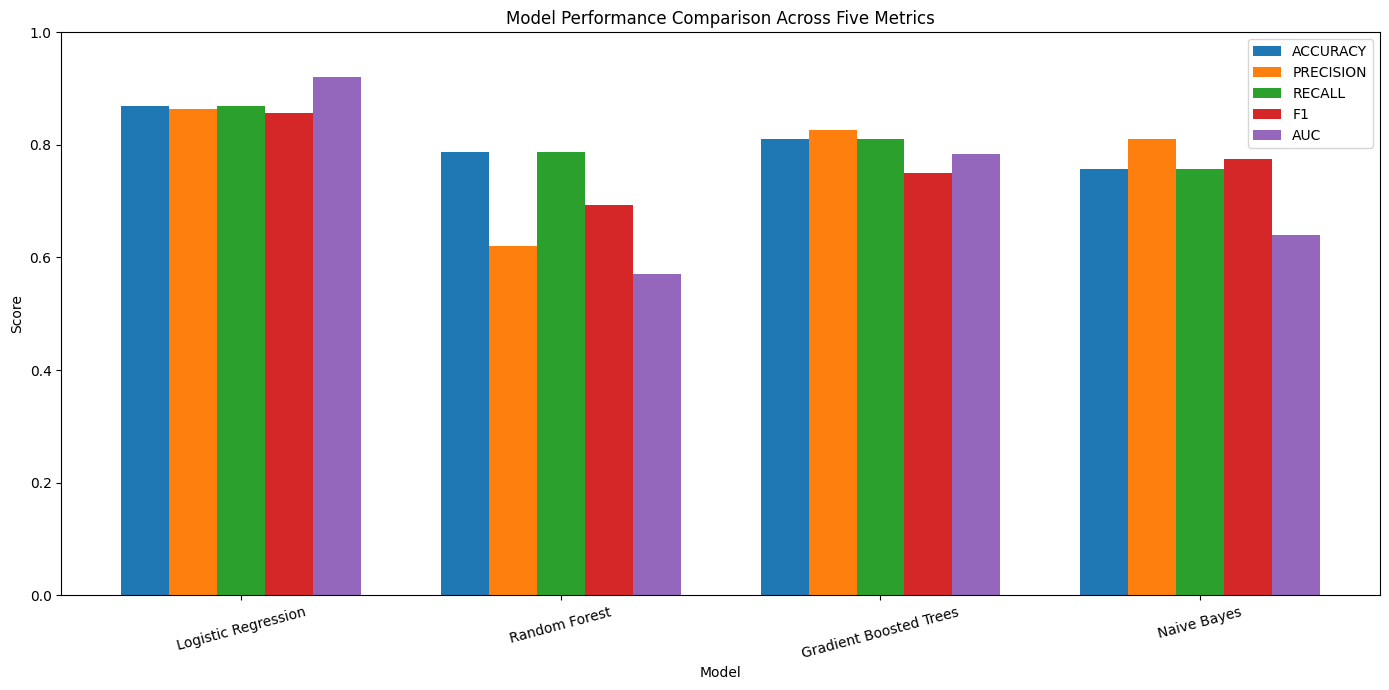

In [7]:
import matplotlib.pyplot as plt

models = list(metrics_results.keys())
metrics = list(evaluators.keys())
x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, [metrics_results[m][metric] for m in models], width, label=metric.upper())

ax.set(xlabel="Model", ylabel="Score", title="Model Performance Comparison Across Five Metrics", ylim=(0, 1))
ax.set_xticks(x + width * 2)
ax.set_xticklabels(models, rotation=15)
ax.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# **8. Confusion Matrices — Counts**

I calculated the raw confusion matrix counts for each model, breaking down true positives, false positives, false negatives, and true negatives before visualising them.

In [8]:
def get_confusion(preds):
    tp = preds.filter((col("prediction") == 1.0) & (col(target) == 1.0)).count()
    fp = preds.filter((col("prediction") == 1.0) & (col(target) == 0.0)).count()
    fn = preds.filter((col("prediction") == 0.0) & (col(target) == 1.0)).count()
    tn = preds.filter((col("prediction") == 0.0) & (col(target) == 0.0)).count()
    return np.array([[tn, fp], [fn, tp]])

confusion_matrices = {name: get_confusion(preds) for name, preds in model_predictions.items()}

for name, matrix in confusion_matrices.items():
    print(f"{name}: TN={matrix[0,0]:,} FP={matrix[0,1]:,} FN={matrix[1,0]:,} TP={matrix[1,1]:,}")

Logistic Regression: TN=1,687 FP=1,668 FN=389 TP=12,044
Random Forest: TN=0 FP=3,355 FN=0 TP=12,433
Gradient Boosted Trees: TN=426 FP=2,929 FN=50 TP=12,383
Naive Bayes: TN=2,352 FP=1,003 FN=2,820 TP=9,613


# **9. Combined Confusion Matrix Grid**

I plotted all four confusion matrices together in a single 2x2 grid, making it easy to compare error patterns across models at a glance.

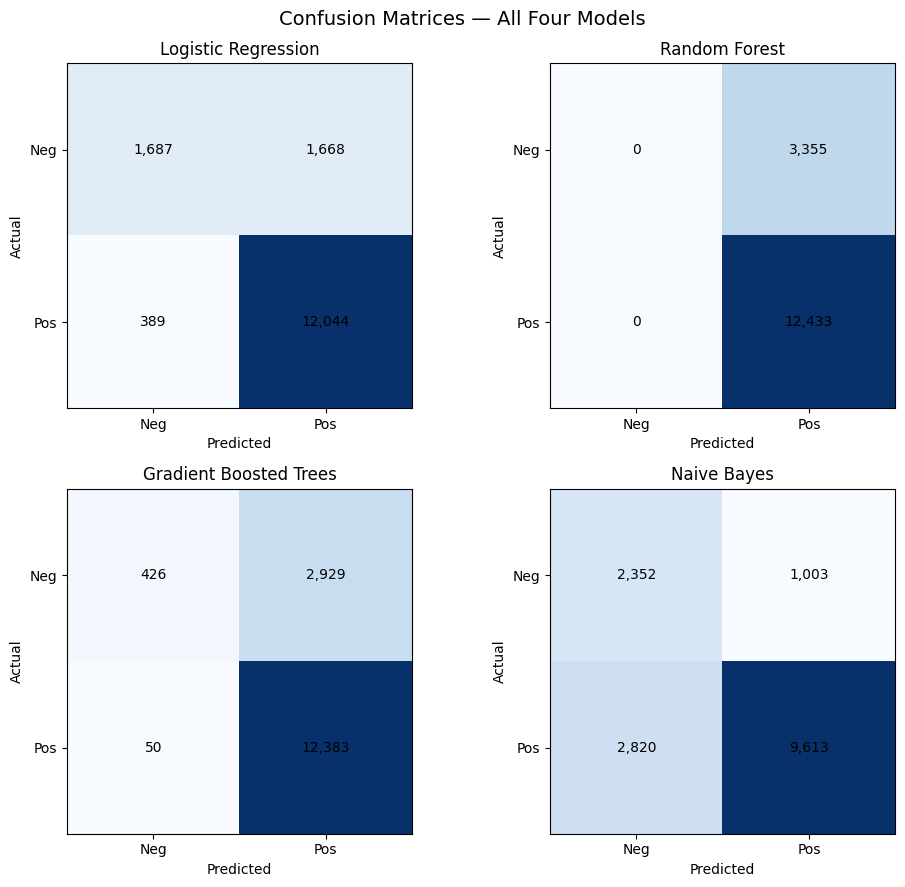

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
fig.suptitle("Confusion Matrices — All Four Models", fontsize=14)

for ax, (name, matrix) in zip(axes.flatten(), confusion_matrices.items()):
    ax.imshow(matrix, cmap="Blues")
    ax.set(title=name, xticks=[0, 1], yticks=[0, 1],
           xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"],
           xlabel="Predicted", ylabel="Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{output_dir}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# **10. ROC and Precision-Recall Curves**

I plotted ROC and PR curves for all four models on the same charts, extracting each model's predicted probability of the Positive class to compare how well they separate the two sentiment classes.

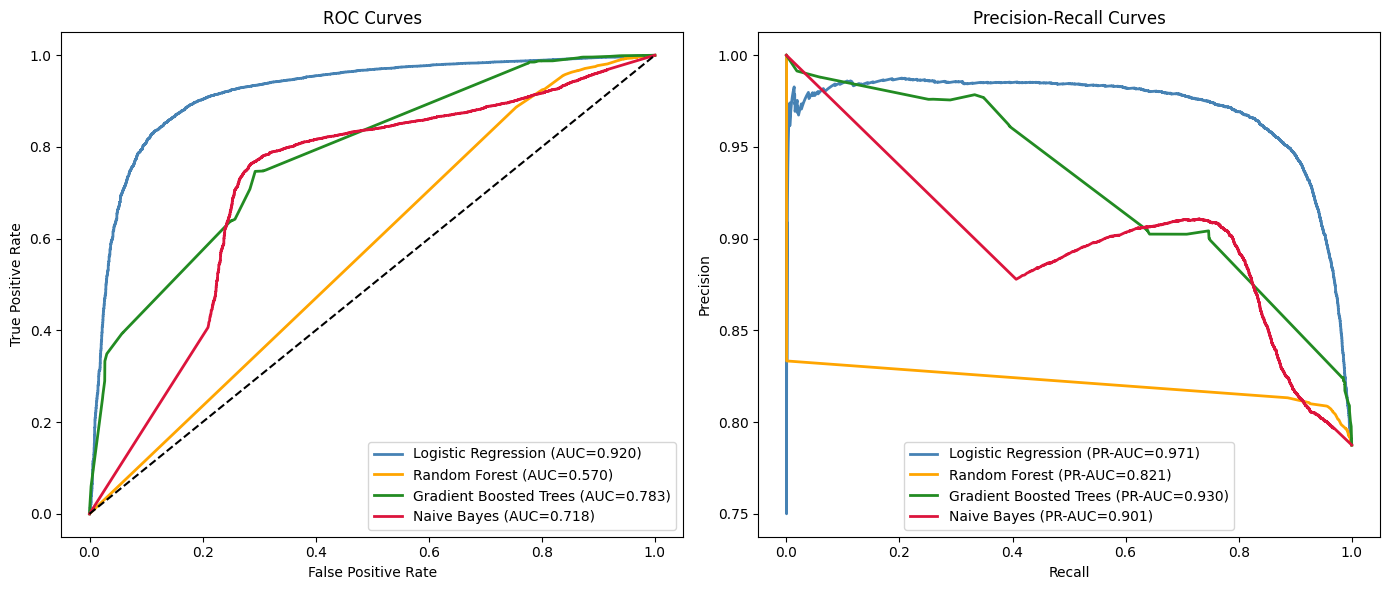

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

get_positive_prob = udf(lambda v: float(v[1]), DoubleType())
colours = ["steelblue", "orange", "forestgreen", "crimson"]

probs = {
    name: (preds.withColumn("p", get_positive_prob(col("probability")))
                 .select("p", col(target).alias("label")).toPandas())
    for name, preds in model_predictions.items()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (name, pdf) in enumerate(probs.items()):
    fpr, tpr, _ = roc_curve(pdf["label"], pdf["p"])
    prec, rec, _ = precision_recall_curve(pdf["label"], pdf["p"])
    axes[0].plot(fpr, tpr, color=colours[i], lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
    axes[1].plot(rec, prec, color=colours[i], lw=2, label=f"{name} (PR-AUC={auc(rec, prec):.3f})")

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curves")
axes[0].legend()
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

# **11. Perturbation Analysis — Adding Noise to All Feature Values**

I added Gaussian noise to every existing non-zero value in each row's sparse vector, covering both the TF-IDF word features and the 5 numeric features. Since each row only has a few dozen non-zero entries out of 65,541 dimensions, perturbing just these keeps the vector sparse and avoids memory issues, while still genuinely affecting the text signal that drives most models' predictions. Negative values are clipped to zero so Naive Bayes never sees an invalid input. A stable model's metrics should barely move when these inputs are slightly noisy.

In [11]:
def add_noise(v, sigma=0.05):
    if isinstance(v, SparseVector):
        indices = v.indices
        values = v.values.copy()
        noise = np.random.normal(0, sigma, len(values))
        values = np.clip(values + noise, 0, None)
        return SparseVector(v.size, indices, values)
    else:
        a = v.toArray()
        a = np.clip(a + np.random.normal(0, sigma, len(a)), 0, None)
        return DenseVector(a)

noise_udf = udf(lambda v: add_noise(v), VectorUDT())
testing_noisy = testing_sample.withColumn("features", noise_udf(col("features")))
print("Noisy test set defined — all existing non-zero feature values perturbed.")

Noisy test set defined — all existing non-zero feature values perturbed.


# **12. Re-scoring and Measuring Metric Drift**

I re-scored each model on the noisy test set and compared it against the clean baseline, measuring how far AUC and accuracy drop. A smaller drop indicates a more stable, more robust model.

In [12]:
import pandas as pd

stability_results = []
for name, model in zip(model_predictions.keys(), [logit_model, forest_model, gbt_model, nbayes_model]):
    base_preds = model_predictions[name]
    noisy_preds = model.transform(testing_noisy)

    auc_base = evaluators["auc"].evaluate(base_preds)
    auc_noisy = evaluators["auc"].evaluate(noisy_preds)
    acc_base = evaluators["accuracy"].evaluate(base_preds)
    acc_noisy = evaluators["accuracy"].evaluate(noisy_preds)

    stability_results.append({
        "Model": name,
        "AUC_base": round(auc_base, 4),
        "AUC_noisy": round(auc_noisy, 4),
        "AUC_drop": round(auc_base - auc_noisy, 4),
        "Acc_base": round(acc_base, 4),
        "Acc_noisy": round(acc_noisy, 4),
        "Acc_drop": round(acc_base - acc_noisy, 4)
    })

stability_df = pd.DataFrame(stability_results).sort_values("AUC_drop")
print(stability_df.to_string(index=False))
print("\nSmallest drop = most stable model.")

                 Model  AUC_base  AUC_noisy  AUC_drop  Acc_base  Acc_noisy  Acc_drop
   Logistic Regression    0.9200     0.9200   -0.0000    0.8697     0.8697    0.0000
         Random Forest    0.5705     0.5705    0.0000    0.7875     0.7875    0.0000
           Naive Bayes    0.6407     0.6407   -0.0000    0.7579     0.7577    0.0001
Gradient Boosted Trees    0.7831     0.7821    0.0011    0.8113     0.8110    0.0003

Smallest drop = most stable model.


# **13. Model Stability Chart — AUC_base and Acc_base**

I plotted each model's baseline AUC and accuracy.

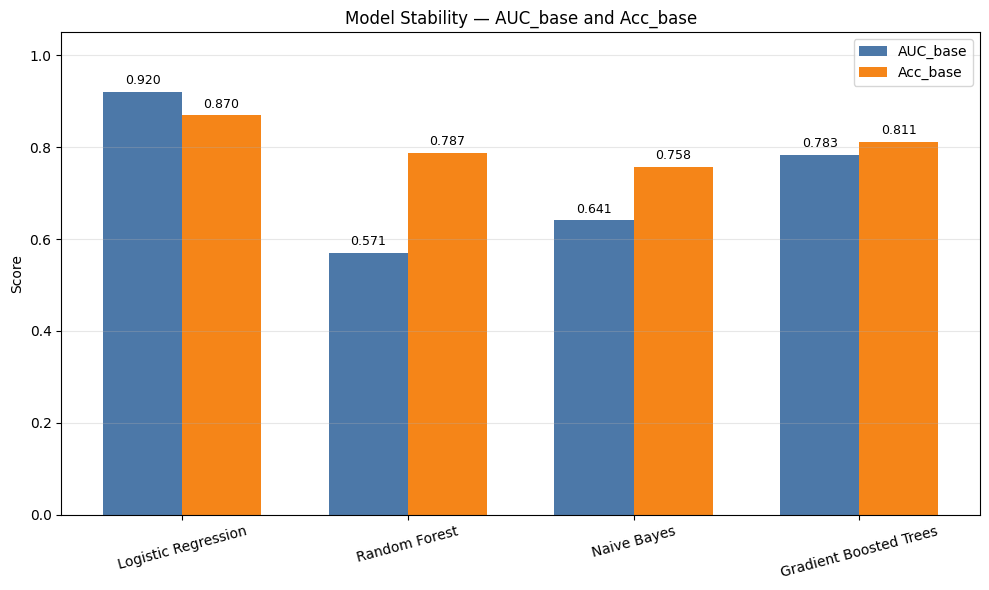

In [13]:
models_list = stability_df["Model"].tolist()
auc_base_vals = stability_df["AUC_base"].values.astype(float)
acc_base_vals = stability_df["Acc_base"].values.astype(float)

x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, auc_base_vals, width, label="AUC_base", color="#4C78A8")
b2 = ax.bar(x + width/2, acc_base_vals, width, label="Acc_base", color="#F58518")

for bars in [b1, b2]:
    for rect in bars:
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                 f"{rect.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Model Stability — AUC_base and Acc_base")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/stability.png", dpi=150, bbox_inches="tight")
plt.show()

# **14. SHAP Feature Importance**

I trained a small sklearn proxy model on a sample of the same features to compute SHAP values, since SHAP doesn't work directly on Spark models.

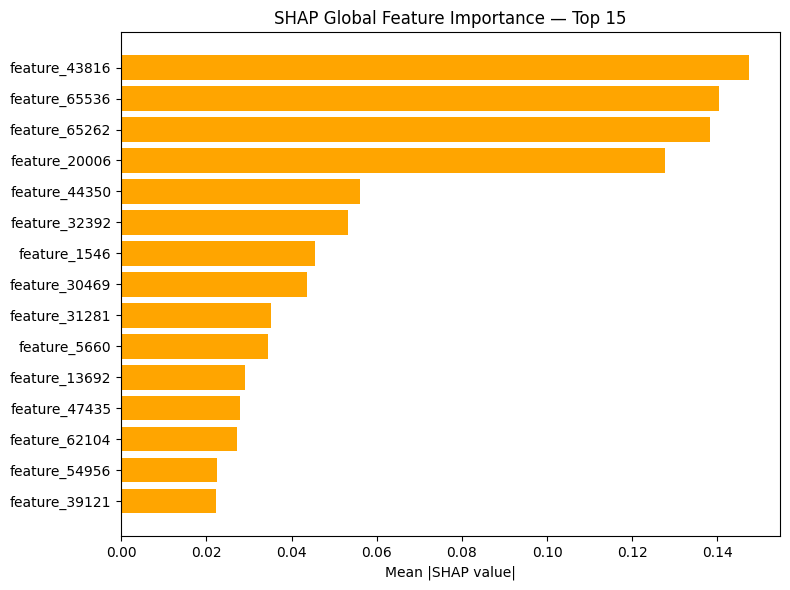

In [14]:
try:
    sample_pdf = testing_sample.select("features", target).limit(300).toPandas()
    X = np.vstack(sample_pdf["features"].apply(lambda v: v.toArray()).values)
    y = sample_pdf[target].values

    from sklearn.ensemble import GradientBoostingClassifier
    import shap

    proxy = GradientBoostingClassifier(n_estimators=30, max_depth=5, random_state=42).fit(X[:250], y[:250])
    shap_values = shap.TreeExplainer(proxy).shap_values(X[250:])

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_15 = np.argsort(-mean_abs_shap)[:15]

    plt.figure(figsize=(8, 6))
    plt.barh([f"feature_{i}" for i in top_15][::-1], mean_abs_shap[top_15][::-1], color="orange")
    plt.xlabel("Mean |SHAP value|")
    plt.title("SHAP Global Feature Importance — Top 15")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/shap.png", dpi=150, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"SHAP skipped: {e}")

# **15. Spark Session Termination**

I terminated the active SparkSession to release allocated memory and cluster resources.

In [15]:
spark.stop()
print("Spark session stopped successfully.")

Spark session stopped successfully.
